ONE-WAY ANOVA TABLE
Source                  SS    df        MS         F
Between groups       62.40     2     31.20    12.480
Within groups        30.00    12      2.50
Total                92.40    14

F critical = 3.885, p-value = 0.001171
scipy f_oneway: F = 12.480, p = 0.001171
Mean yield of Fertilizer A = 21.20
Mean yield of Fertilizer B = 26.00
Mean yield of Fertilizer C = 22.40

Decision: Reject H0 -> At least one fertilizer gives a different average yield.


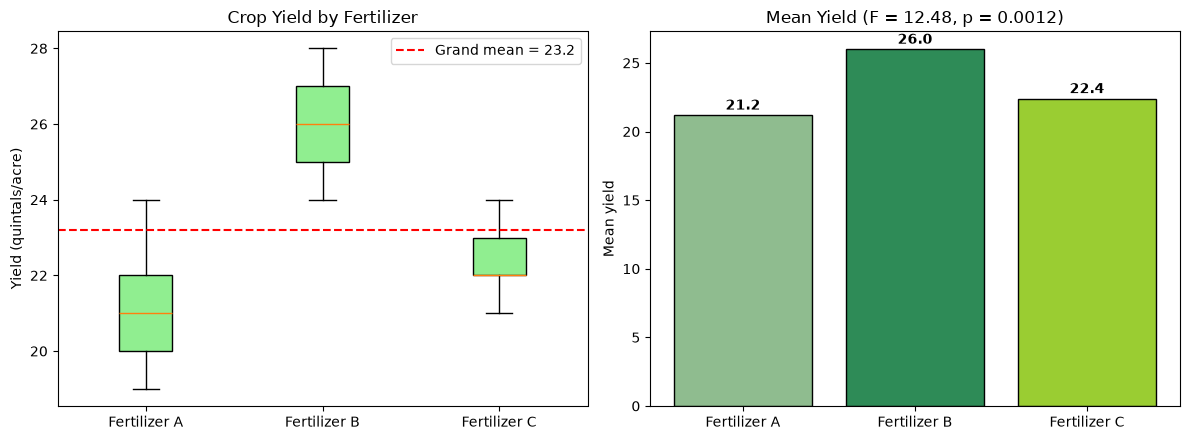

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - yield (quintals/acre)
fert_A = np.array([20, 22, 19, 24, 21])
fert_B = np.array([25, 27, 24, 26, 28])
fert_C = np.array([22, 23, 21, 24, 22])

groups = [fert_A, fert_B, fert_C]
names = ['Fertilizer A', 'Fertilizer B', 'Fertilizer C']
alpha = 0.05

# Step 2: ANOVA table calculated step by step

all_data = np.concatenate(groups)

grand_mean = all_data.mean()

k = len(groups)
N = len(all_data)

# Between-group variation
SSB = sum(
    len(g) * (g.mean() - grand_mean) ** 2
    for g in groups
)

# Within-group variation
SSW = sum(
    ((g - g.mean()) ** 2).sum()
    for g in groups
)

# Total variation
SST = SSB + SSW

# Degrees of freedom
df_b = k - 1
df_w = N - k

# Mean squares
MSB = SSB / df_b
MSW = SSW / df_w

# F statistic
F = MSB / MSW

# p-value
p_value = 1 - stats.f.cdf(F, df_b, df_w)

# Critical F value
F_critical = stats.f.ppf(
    1 - alpha,
    df_b,
    df_w
)

# Print ANOVA table
print("ONE-WAY ANOVA TABLE")
print(
    f"{'Source':<16}"
    f"{'SS':>10}"
    f"{'df':>6}"
    f"{'MS':>10}"
    f"{'F':>10}"
)

print(
    f"{'Between groups':<16}"
    f"{SSB:>10.2f}"
    f"{df_b:>6}"
    f"{MSB:>10.2f}"
    f"{F:>10.3f}"
)

print(
    f"{'Within groups':<16}"
    f"{SSW:>10.2f}"
    f"{df_w:>6}"
    f"{MSW:>10.2f}"
)

print(
    f"{'Total':<16}"
    f"{SST:>10.2f}"
    f"{N - 1:>6}"
)

print(
    f"\nF critical = {F_critical:.3f}, "
    f"p-value = {p_value:.6f}"
)

# Step 3: Check with scipy
F_scipy, p_scipy = stats.f_oneway(
    fert_A,
    fert_B,
    fert_C
)

print(
    f"scipy f_oneway: F = {F_scipy:.3f}, "
    f"p = {p_scipy:.6f}"
)

# Step 4: Decision

for name, g in zip(names, groups):
    print(
        f"Mean yield of {name} = {g.mean():.2f}"
    )

if p_value < alpha:
    print(
        "\nDecision: Reject H0 -> "
        "At least one fertilizer gives a different average yield."
    )
else:
    print(
        "\nDecision: Fail to reject H0 -> "
        "All fertilizers give the same average yield."
    )

# Step 5: Graphs

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

# Boxplot
ax[0].boxplot(
    groups,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen')
)

ax[0].set_xticks([1, 2, 3])
ax[0].set_xticklabels(names)

ax[0].axhline(
    grand_mean,
    color='red',
    linestyle='--',
    label=f'Grand mean = {grand_mean:.1f}'
)

ax[0].set_title('Crop Yield by Fertilizer')
ax[0].set_ylabel('Yield (quintals/acre)')
ax[0].legend(loc='upper right')

# Mean bar chart
means = [
    g.mean()
    for g in groups
]

ax[1].bar(
    names,
    means,
    color=['#8fbc8f', '#2e8b57', '#9acd32'],
    edgecolor='black'
)

for i, m in enumerate(means):
    ax[1].text(
        i,
        m + 0.4,
        f'{m:.1f}',
        ha='center',
        fontweight='bold'
    )

ax[1].set_title(
    f'Mean Yield (F = {F:.2f}, p = {p_value:.4f})'
)

ax[1].set_ylabel('Mean yield')

plt.tight_layout()
plt.show()